<a href="https://colab.research.google.com/github/hk666890/SEM-VI--A2/blob/main/IPMV_Exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Standard 4-connected Chain Code for the square: [1, 0, 3, 2]


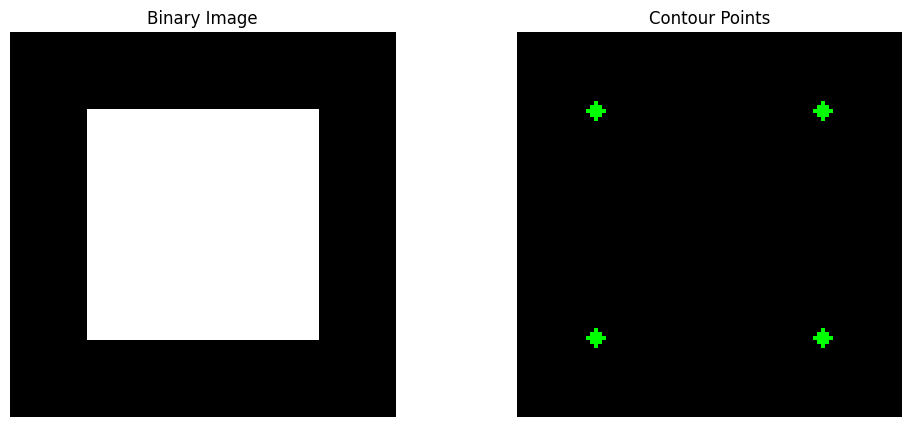

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def exp7_chain_code():
    # --------------------------------------------------------
    # STEP 1: Create a simple binary image
    # --------------------------------------------------------
    img = np.zeros((100, 100), dtype=np.uint8)
    # Create a white square in black background
    img[20:80, 20:80] = 255

    # --------------------------------------------------------
    # STEP 2: Find contours
    # --------------------------------------------------------
    # Use cv2.RETR_EXTERNAL to retrieve only external contours
    # Use cv2.CHAIN_APPROX_NONE to store all contour points
    contours, _ = cv2.findContours(img,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_NONE)
    # Select the largest contour
    contour = max(contours, key=len)

    # --------------------------------------------------------
    # STEP 3: Approximate contour
    # --------------------------------------------------------
    # Approximate contour with a polygon. epsilon is the maximum distance between the original contour and its approximation.
    epsilon = 0.01 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)

    # --------------------------------------------------------
    # STEP 4: Generate Chain Code (Standard 4-connected)
    # --------------------------------------------------------
    # For a closed contour, the loop should include the segment from the last point to the first.
    # Standard 4-connected directions:
    # 0: Right (dx > 0, dy == 0)
    # 1: Down  (dx == 0, dy > 0)
    # 2: Left  (dx < 0, dy == 0)
    # 3: Up    (dx == 0, dy < 0)

    chain_code = []
    for i in range(len(approx)):
        p1 = approx[i][0] # Current point
        p2 = approx[(i + 1) % len(approx)][0] # Next point (wraps around for closed contour)

        dx = p2[0] - p1[0]
        dy = p2[1] - p1[1]

        if dx > 0 and dy == 0:
            chain_code.append(0)  # Right
        elif dx == 0 and dy > 0:
            chain_code.append(1)  # Down
        elif dx < 0 and dy == 0:
            chain_code.append(2)  # Left
        elif dx == 0 and dy < 0:
            chain_code.append(3)  # Up
        # For diagonals or zero movement, no code is added in this 4-connected scheme.

    print(f"Standard 4-connected Chain Code for the square: {chain_code}")

    # --------------------------------------------------------
    # STEP 5: Display Results
    # --------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Binary Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    contour_img = np.zeros((100, 100, 3), dtype=np.uint8)
    for p in approx:
        cv2.circle(contour_img, tuple(p[0]), 2, (0, 255, 0), -1)
    plt.imshow(contour_img)
    plt.title("Contour Points")
    plt.axis('off')
    plt.show()

# Execute experiment
exp7_chain_code()